In [20]:
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("student_habits_performance.csv")

In [7]:
df.shape

(1000, 16)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [8]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [13]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1000,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


In [10]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


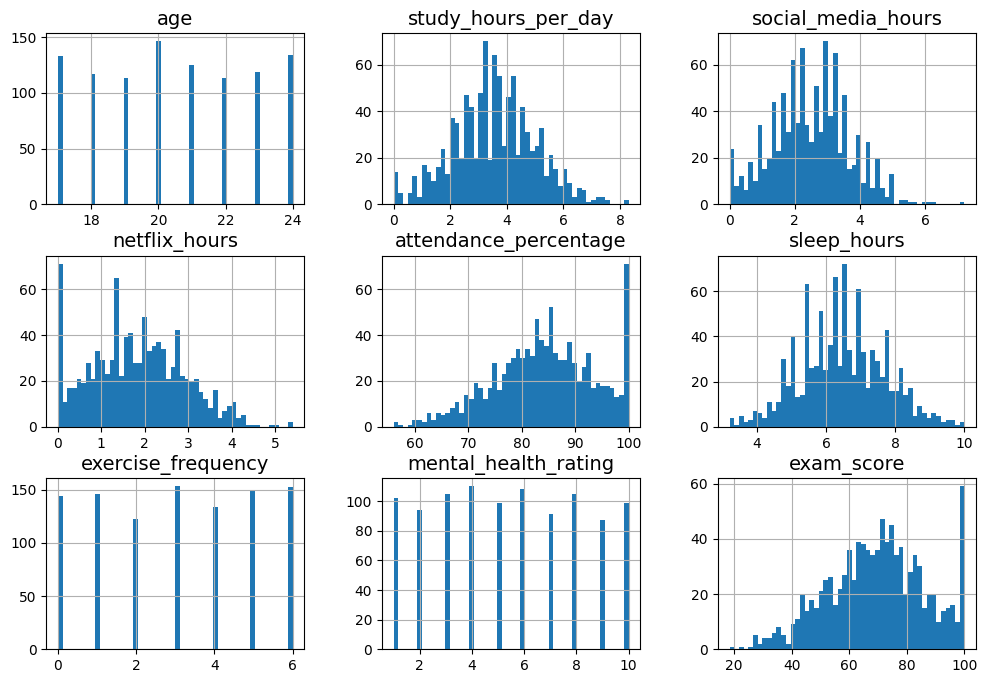

In [30]:
df.hist(bins=50, figsize=(12, 8))
plt.ticklabel_format(style="plain", axis="x")
plt.show()


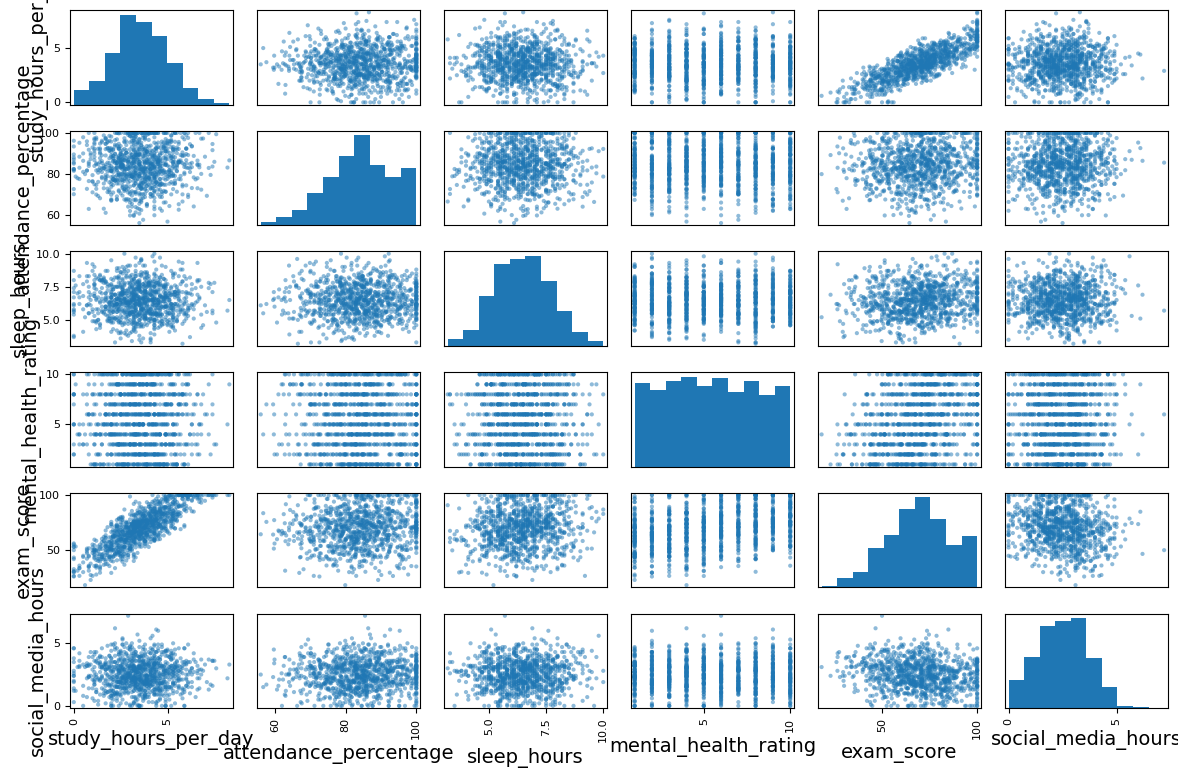

In [ ]:
from pandas.plotting import scatter_matrix

attributes = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "mental_health_rating",
    "exam_score",
    "social_media_hours",
]


scatter_matrix(df[attributes], figsize=(12, 8))
plt.tight_layout()
plt.show()

In [37]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000,0.004,-0.009,-0.001,-0.026,0.037,-0.004,-0.045,-0.009
study_hours_per_day,0.004,1.000,0.020,-0.031,0.026,-0.028,-0.029,-0.004,0.825
social_media_hours,-0.009,0.020,1.000,0.011,0.040,0.018,-0.037,0.001,-0.167
netflix_hours,-0.001,-0.031,0.011,1.000,-0.002,-0.001,-0.006,0.008,-0.172
attendance_percentage,-0.026,0.026,0.040,-0.002,1.000,0.014,-0.008,-0.019,0.090
sleep_hours,0.037,-0.028,0.018,-0.001,0.014,1.000,0.020,-0.007,0.122
exercise_frequency,-0.004,-0.029,-0.037,-0.006,-0.008,0.020,1.000,-0.000,0.160
mental_health_rating,-0.045,-0.004,0.001,0.008,-0.019,-0.007,-0.000,1.000,0.322
exam_score,-0.009,0.825,-0.167,-0.172,0.090,0.122,0.160,0.322,1.000


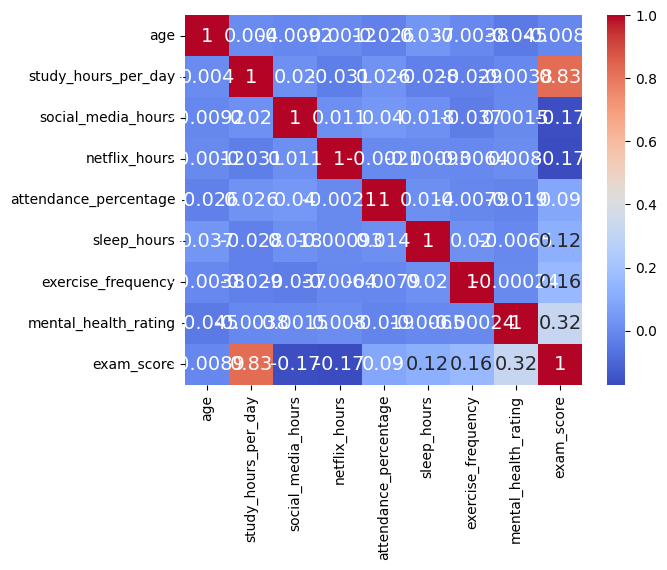

In [ ]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [41]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

df.drop(
    [
        "student_id",
        "age",
        "gender",
    ],
    axis=1,
    inplace=True,
)

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

train_features = train_set.drop("exam_score", axis=1)
train_labels = train_set["exam_score"].copy()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector, make_column_transformer


cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    # StandardScaler(),
)

preprocessor = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)


In [47]:
preprocessed_data = pd.DataFrame(
    preprocessor.fit_transform(train_features),
    columns=preprocessor.get_feature_names_out(),
)
preprocessed_data.head()

,pipeline-1__study_hours_per_day,pipeline-1__social_media_hours,pipeline-1__netflix_hours,pipeline-1__attendance_percentage,pipeline-1__sleep_hours,pipeline-1__exercise_frequency,pipeline-1__mental_health_rating,pipeline-2__part_time_job_No,pipeline-2__part_time_job_Yes,pipeline-2__diet_quality_Fair,pipeline-2__diet_quality_Good,pipeline-2__diet_quality_Poor,pipeline-2__parental_education_level_Bachelor,pipeline-2__parental_education_level_High School,pipeline-2__parental_education_level_Master,pipeline-2__internet_quality_Average,pipeline-2__internet_quality_Good,pipeline-2__internet_quality_Poor,pipeline-2__extracurricular_participation_No,pipeline-2__extracurricular_participation_Yes
0,-1.050,0.613,1.813,-0.176,0.192,1.456,1.592,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000
1,1.915,1.469,-0.294,0.483,-0.298,-1.525,0.189,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
2,-0.713,-0.501,-0.202,0.993,0.437,0.463,0.891,1.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000
3,0.163,0.955,2.271,1.673,0.682,-1.028,0.540,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000
4,-0.039,0.270,-1.668,0.823,-2.175,0.959,-0.162,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000
